# Causal Analysis

This notebook requires the raw latents, which you can compute with the [`compute_latents.py`](./compute_latents.py) notebook.

## Setup

In [24]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from tigramite import data_processing as pp
from tigramite import plotting as tp
from tigramite.independence_tests.cmiknn import CMIknn
from tigramite.independence_tests.cmisymb import CMIsymb
from tigramite.independence_tests.gpdc_torch import GPDCtorch
from tigramite.independence_tests.gsquared import Gsquared
from tigramite.independence_tests.parcorr import ParCorr
from tigramite.independence_tests.robust_parcorr import RobustParCorr
from tigramite.lpcmci import LPCMCI

from csi_vae_gumbel.settings import Settings

settings = Settings()

INDEPENDENCE_TEST = "robustparcorr"
"""Independence tests to consider:"""
FILTER_THRESHOLD = 0.2
"""Minimum MCI strength under which to filter out edges in the causal graph."""
TAU_MIN = 1
"""Minimum time lag to consider for causal links. Set to 1 to exclude contemporaneous links."""
TAU_MAX = settings.test_window_size // settings.train_window_size - 1
"""Maximum time lag to consider for causal links. Set to the maximum possible given the window sizes."""

is_test_categorical = INDEPENDENCE_TEST in ["cmiknn", "gsquared", "cmisymb"]

match INDEPENDENCE_TEST:
    case "parcorr":
        ind_test = ParCorr(significance="analytic")
    case "robustparcorr":
        ind_test = RobustParCorr(significance="analytic")
    case "gpdc":
        ind_test = GPDCtorch()
    case "gsquared":
        ind_test = Gsquared()
    case "cmisymb":
        ind_test = CMIsymb()
    case "cmiknn":
        ind_test = CMIknn()
    case _:
        msg = f"Unknown independence test: {INDEPENDENCE_TEST}"
        raise ValueError(msg)

## Dataset

We use the complete dataset for causal inference, without any train/test split.

In [25]:
# Shape will be (T, latent_dim, n_categories)
latents = np.load(f"../{settings.study_path}/latents/latents_{'hard' if is_test_categorical else 'soft'}.npy")

# Shape will be (T,)
labels = np.load(f"../{settings.study_path}/latents/labels.npy")

# Each variable is a specific category-latent dimension pair
var_names = [f"C{i}_Z{j}" for i in range(latents.shape[2]) for j in range(latents.shape[1])]

# Flatten the latents so that each category-latent dimension pair is treated as a separate variable
# Shape will be (T, latent_dim * n_categories)
latents = latents.reshape(latents.shape[0], -1)

dataset = {}

# Split and then shift per activity
for label in np.unique(labels):
    # Extract latents for this specific movement sequence
    activity_latents = latents[labels == label]

    # Downsample to match the test window size
    # (e.g., if train_window_size=75 and test_window_size=450, take every 6th time step)
    activity_latents = activity_latents[:: settings.train_window_size]
    dataset[int(label)] = activity_latents

## Causal Analysis

This may take a while to run.

In [ ]:
for label_id, data in dataset.items():
    activity_name = settings.activities[label_id]

    data_type = np.ones_like(data) if is_test_categorical else np.zeros_like(data)
    dataframe = pp.DataFrame(data, var_names=var_names, data_type=data_type)

    lpcmci = LPCMCI(dataframe=dataframe, cond_ind_test=ind_test)

    # Low pc_alpha is more stringent and results in fewer edges, which can help with interpretability
    result = lpcmci.run_lpcmci(
        tau_min=TAU_MIN,
        tau_max=TAU_MAX,
        pc_alpha=1e-3,
    )

    # Save the results for later analysis
    out_dir = Path(f"../{settings.study_path}/causal_analysis/{INDEPENDENCE_TEST}")
    out_dir.mkdir(parents=True, exist_ok=True)
    np.save(out_dir / f"{activity_name}_val_matrix.npy", result["val_matrix"])
    np.save(out_dir / f"{activity_name}_graph.npy", result["graph"])

## Visualization

GSquared does not distinguish between positive and negative correlations, so we need to compute the correlation matrix separately to determine the sign of each relationship. We will use Pearson correlation for this purpose, which is appropriate for continuous variables.

In [21]:
def compute_gsquared_signs(data: np.ndarray, val_matrix: np.ndarray) -> None:
    """For each link found by Tigramite (nonzero in val_matrix), compute the Spearman correlation."""
    n_vars = val_matrix.shape[0]

    for i in range(n_vars):
        for j in range(n_vars):
            for tau in range(TAU_MIN, TAU_MAX + 1):
                # If Tigramite found a link (nonzero value in val_matrix)
                strength = val_matrix[i, j, tau]

                if strength > 0:  # G2 values are always positive
                    # Get the two time-series aligned by the lag (tau)
                    # X is the cause (at t - tau), Y is the effect (at t)
                    y_series = data[tau:, j]
                    x_series = data[:-tau, i]

                    # Calculate Spearman correlation to find the sign
                    res = stats.spearmanr(x_series, y_series)
                    rho = res.statistic  # pyright: ignore[reportAttributeAccessIssue]

                    # OPTIONAL: Manually update val_matrix with the sign for plotting
                    # This makes the red/blue plot work correctly
                    val_matrix[i, j, tau] *= np.sign(rho)

Walk


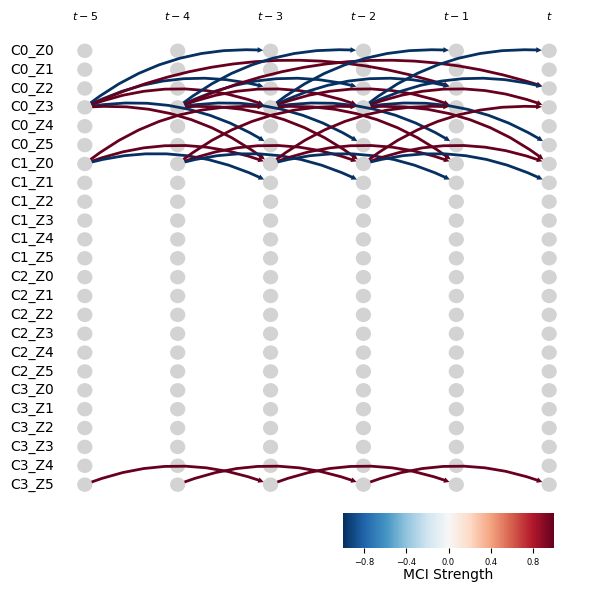

Run


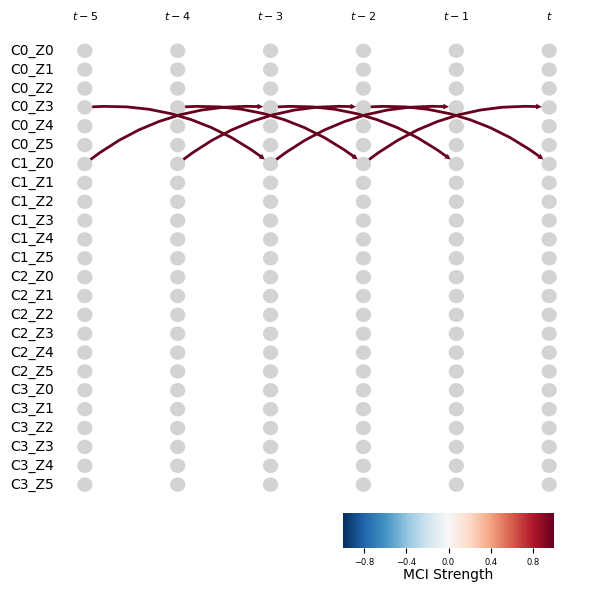

Jump


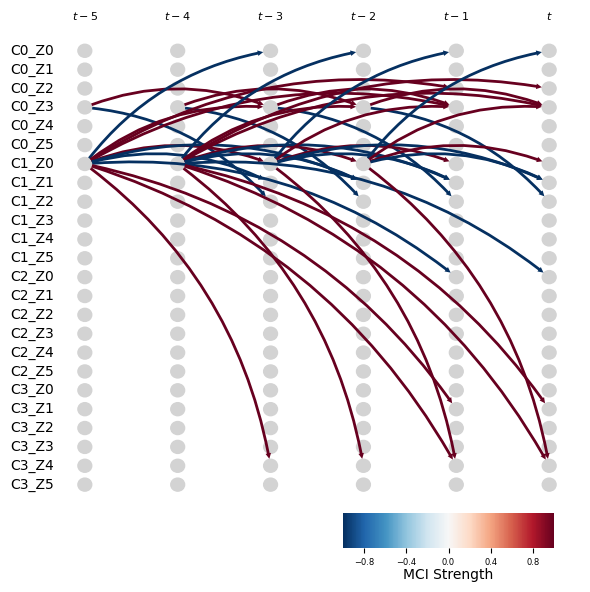

Sit


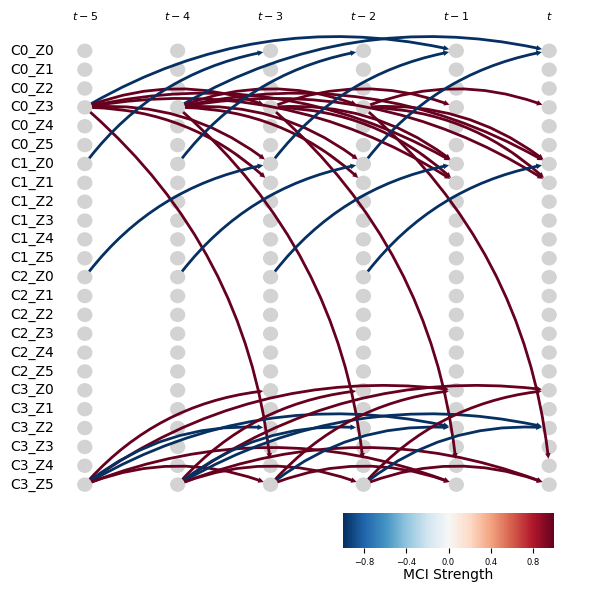

Empty


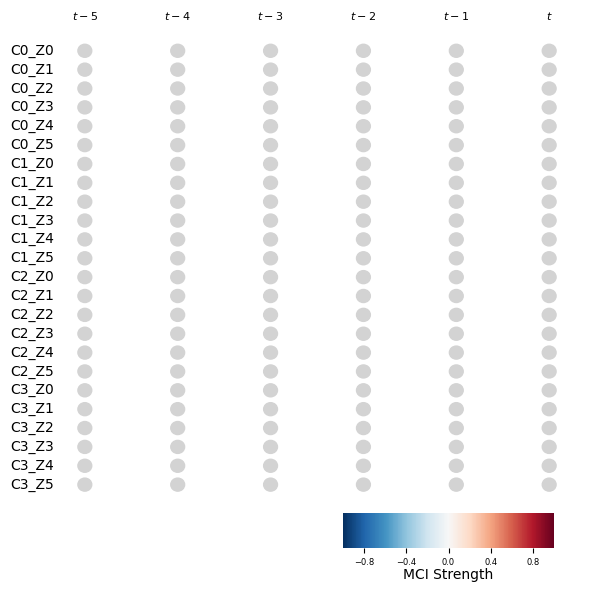

Stand


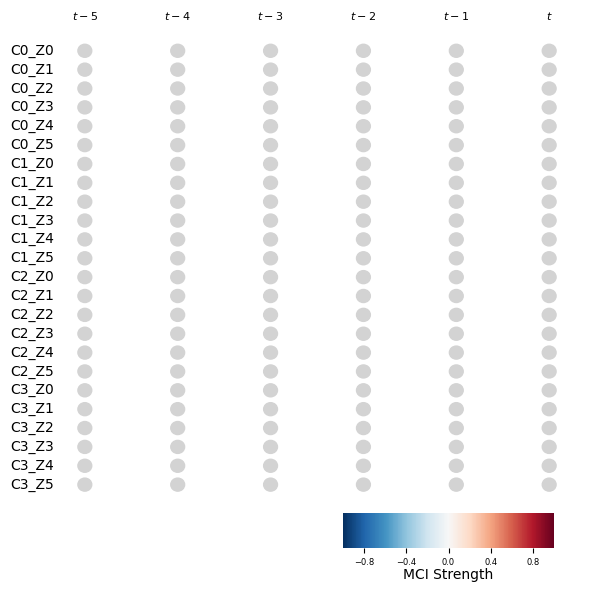

Waving


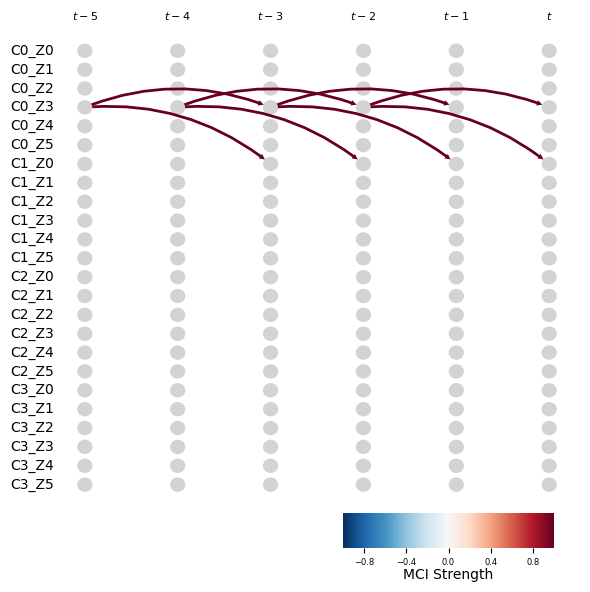

Clap


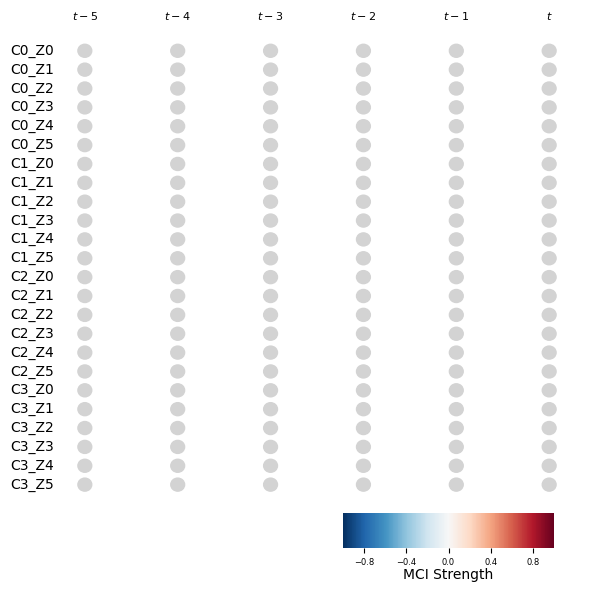

Lay down


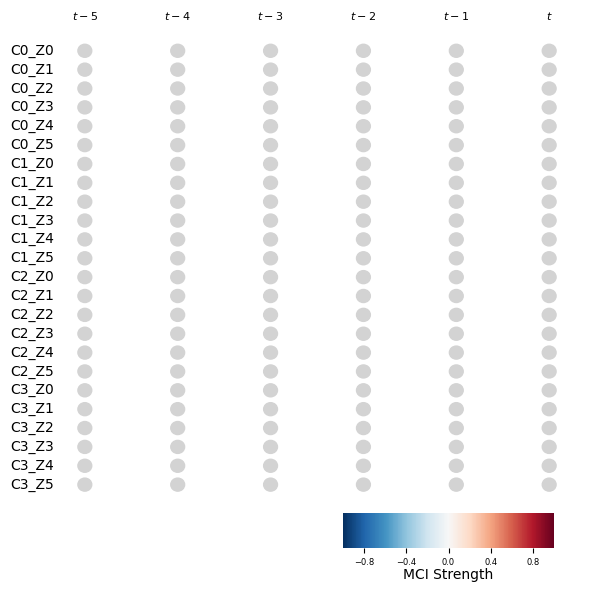

Wipe


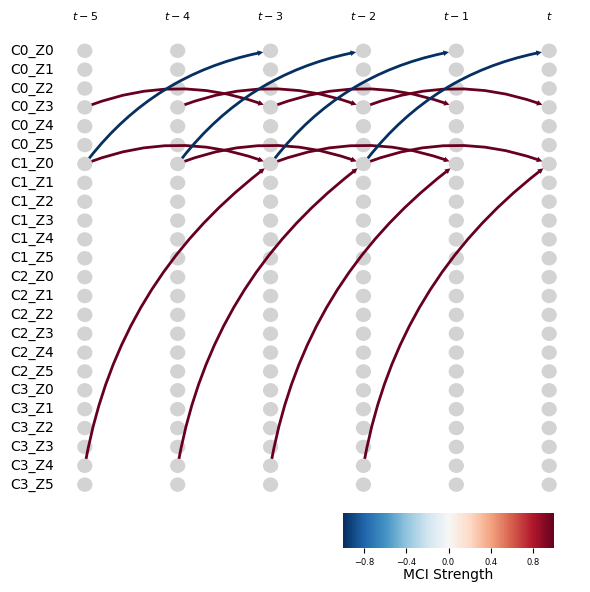

Squat


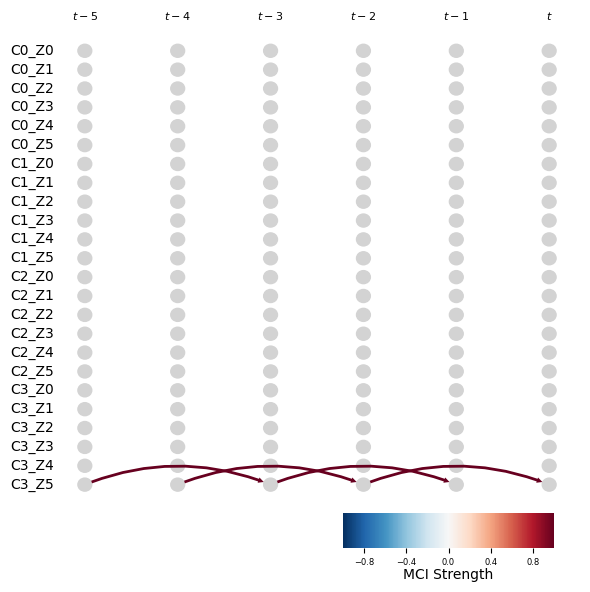

Stretch


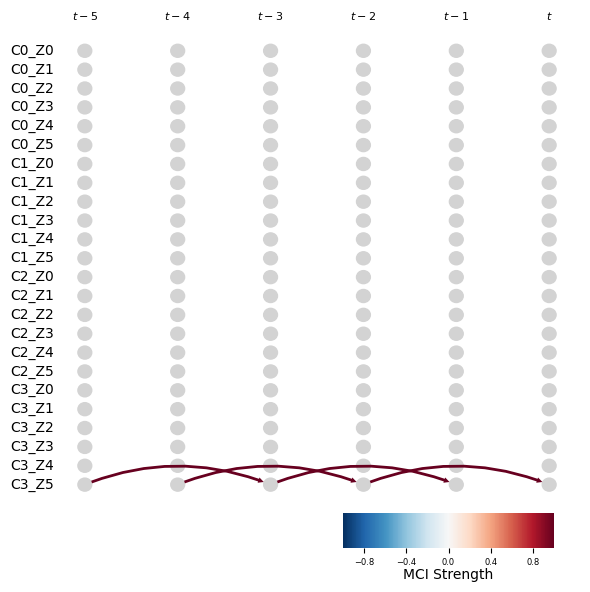

In [22]:
for activity_name in settings.activities:
    out_dir = Path(f"../{settings.study_path}/causal_analysis/{INDEPENDENCE_TEST}")
    val_matrix = np.load(out_dir / f"{activity_name}_val_matrix.npy")
    graph = np.load(out_dir / f"{activity_name}_graph.npy")

    if INDEPENDENCE_TEST == "gsquared":
        compute_gsquared_signs(data, val_matrix)

    # Find indices where the absolute strength is below the threshold and zero them
    weak_links = np.abs(val_matrix) < FILTER_THRESHOLD
    val_matrix[weak_links] = 0
    graph[weak_links] = ""

    # Remove bidirected (confounded) links for better interpretability
    for i in range(graph.shape[0]):
        for j in range(graph.shape[1]):
            for tau in range(graph.shape[2]):
                # Remove bidirected (confounded) links
                if graph[i, j, tau] == "<->" or "o" in graph[i, j, tau]:
                    graph[i, j, tau] = ""
                    val_matrix[i, j, tau] = 0

    print(activity_name)

    fig, ax = tp.plot_time_series_graph(
        figsize=(6,6),
        arrow_linewidth=2,
        arrowhead_size=10,
        node_size=0.03,
        val_matrix=val_matrix,
        graph=graph,
        var_names=var_names,
        link_colorbar_label="MCI Strength",
    )

    plt.tight_layout()
    plt.savefig(out_dir / f"{activity_name}.pdf")
    plt.show()

## BN Rules

In [23]:
def generate_rules(graph: np.ndarray, val_matrix: np.ndarray, vars: list[str], threshold: float = 0.1):
    n_vars, _, max_tau = graph.shape

    ltl_rules = []
    problog_rules = []

    # Iterate through effect variables (j) and their potential causes (i)
    for j in range(n_vars):
        for i in range(n_vars):
            for tau in range(1, max_tau):  # Paper focuses on lagged relationships n={1,2,3}
                if graph[i, j, tau] == "-->" and abs(val_matrix[i, j, tau]) > threshold:
                    strength = val_matrix[i, j, tau]
                    cause = vars[i]
                    effect = vars[j]

                    # 1. Generate LTL Syntax
                    # Example: Box(fA => O uL)
                    next_ops = "O" * tau
                    sign = "" if strength > 0 else "!"
                    ltl_rules.append(f"Box({cause} => {next_ops}{sign}{effect})")

                    # 2. Generate ProbLog Syntax (Grounded for T=1 to T=2)
                    # Example: uL2 :- fA1.
                    problog_rules.append(f"{effect}2 :- {cause}1.")

    return ltl_rules, problog_rules


# --- Usage Example ---
# Assuming 'results' is your Tigramite output dictionary
var_names = ["uA", "fA", "uLL", "uL", "lL"]  # From Section III-A of the paper
ltl, problog = generate_rules(results["graph"], results["val_matrix"], var_names, threshold=0.1)

print("--- LTL Rules (Per Paper Section III-C) ---")
for rule in ltl:
    print(rule)

print("\n--- ProbLog Grounding (Per Paper Section IV-D) ---")
for rule in problog:
    print(rule)

KeyError: 'graph'